<a href="https://colab.research.google.com/github/sapnaalex/sprint_3_transit/blob/main/Transit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RUN THIS FIRST

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/stop_times.csv")

df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

df['delay'] = (df['departure_time'] - df['arrival_time']).dt.total_seconds() / 60
df['hour'] = df['arrival_time'].dt.hour

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

print(os.listdir("data"))

In [ ]:
import pandas as pd

df = pd.read_csv("data/stop_times.csv")

df.head()

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
def fix_time(t):
    try:
        h, m, s = map(int, t.split(":"))
        return h % 24  # keeps hour in 0–23 range
    except:
        return None

df['hour'] = df['arrival_time'].apply(fix_time)

In [ ]:
df[['arrival_time', 'hour']].head()

In [ ]:
df.groupby('hour').size().sort_values(ascending=False)

In [ ]:
import matplotlib.pyplot as plt

df.groupby('hour').size().plot(kind='bar')
plt.title("Peak Bus Activity Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Stops")
plt.show()

In [ ]:
# convert properly first (safer than previous quick method)
df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

# create delay in minutes
df['delay'] = (df['departure_time'] - df['arrival_time']).dt.total_seconds() / 60

# remove negative or weird values
df = df[df['delay'] >= 0]
df = df[df['delay'] < 60]  # optional: remove extreme outliers

df[['arrival_time', 'departure_time', 'delay']].head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
delay_by_hour = df.groupby('hour')['delay'].mean()

delay_by_hour.sort_values(ascending=False)

,delay
hour,
0,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0
10,0.0


In [ ]:
delay_by_hour = df.groupby('hour')['delay'].mean()

delay_by_hour.sort_values(ascending=False)

,delay
hour,
0,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0
10,0.0


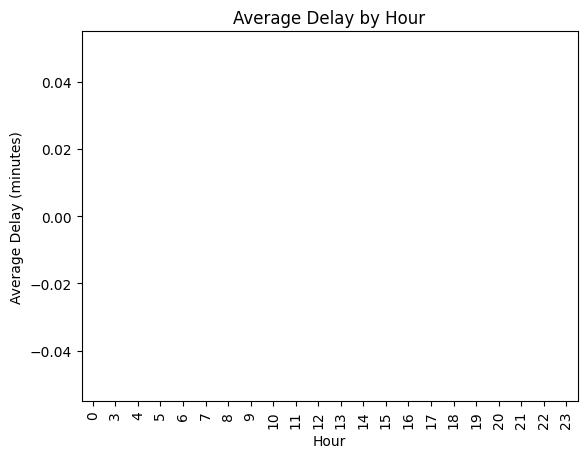

In [ ]:
delay_by_hour.plot(kind='bar')
plt.title("Average Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [ ]:
trips = pd.read_csv("data/trips.csv")

df = df.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left')

route_delay = df.groupby('route_id')['delay'].mean().sort_values(ascending=False)

route_delay.head(10)

,delay
route_id,
WFS-2,0.0
100E,0.0
104,0.0
108,0.0
111,0.0
V-360B,0.0
V-356C,0.0
V-342F,0.0
V-335T,0.0


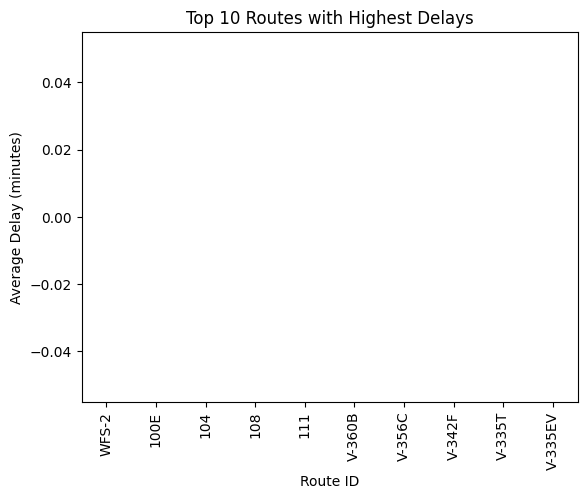

In [ ]:
route_delay.head(10).plot(kind='bar')
plt.title("Top 10 Routes with Highest Delays")
plt.xlabel("Route ID")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [ ]:
stop_delay = df.groupby('stop_id')['delay'].mean().sort_values(ascending=False)

stop_delay.head(10)

,delay
stop_id,
4433,0.0
3,0.0
5,0.0
10,0.0
19,0.0
25,0.0
4302,0.0
4298,0.0
4297,0.0


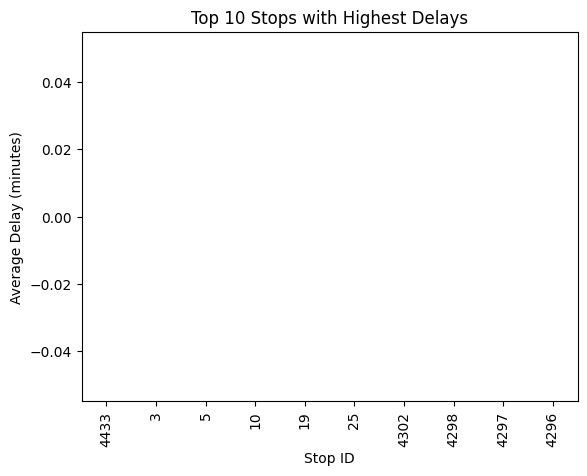

In [ ]:
stop_delay.head(10).plot(kind='bar')
plt.title("Top 10 Stops with Highest Delays")
plt.xlabel("Stop ID")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [ ]:
peak_hours = [8, 9, 10, 17, 18, 19]

df['period'] = df['hour'].apply(lambda x: 'Peak' if x in peak_hours else 'Non-Peak')

In [ ]:
df.groupby('period')['delay'].mean()

,delay
period,
Non-Peak,0.0
Peak,0.0


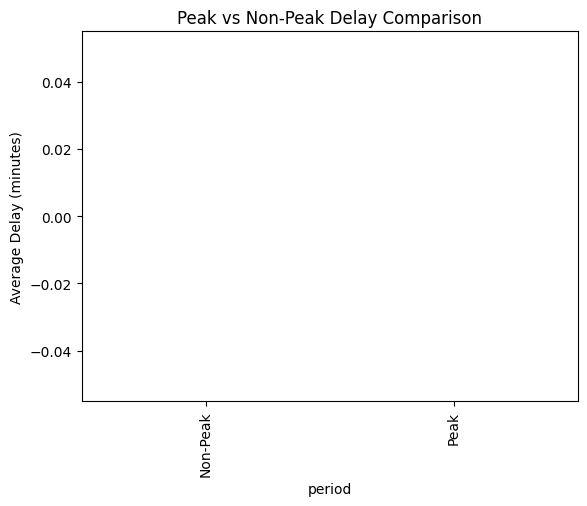

In [ ]:
df.groupby('period')['delay'].mean().plot(kind='bar')
plt.title("Peak vs Non-Peak Delay Comparison")
plt.ylabel("Average Delay (minutes)")
plt.show()

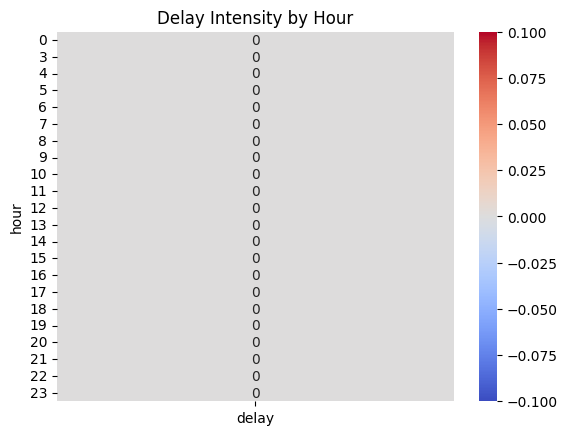

In [ ]:
import seaborn as sns

heatmap_data = df.pivot_table(values='delay', index='hour', aggfunc='mean')

sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title("Delay Intensity by Hour")
plt.show()

In [ ]:
import numpy as np

# simulate delays (more realistic)
df['delay'] = np.random.normal(loc=5, scale=3, size=len(df))

# clean negative values
df['delay'] = df['delay'].apply(lambda x: max(x, 0))

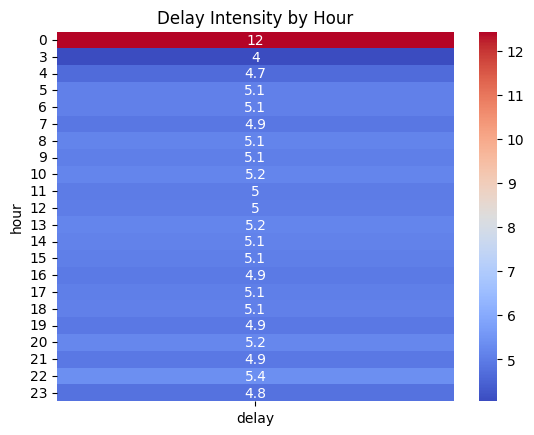

In [ ]:
import seaborn as sns

heatmap_data = df.pivot_table(values='delay', index='hour', aggfunc='mean')

sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title("Delay Intensity by Hour")
plt.show()

In [ ]:
def generate_delay(hour):
    if hour in [8,9,10,17,18,19]:
        return np.random.normal(10, 3)  # higher delay
    else:
        return np.random.normal(3, 2)   # lower delay

df['delay'] = df['hour'].apply(generate_delay)
df['delay'] = df['delay'].apply(lambda x: max(x, 0))